<a href="https://colab.research.google.com/github/ElMad6261/spotify-music-analysis/blob/main/02_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Verificar qué hay en la carpeta
path = '/content/drive/MyDrive/spotify-analysis/data/processed/'
if os.path.exists(path):
    print("Archivos encontrados:", os.listdir(path))
else:
    print("Carpeta no existe — hay que regenerar el archivo")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archivos encontrados: ['dataset_clean.csv']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo consistente para todas las gráficas
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_csv('/content/drive/MyDrive/spotify-analysis/data/processed/dataset_clean.csv')
print("Shape:", df.shape)

Shape: (113999, 22)


In [ ]:
import os

# Crear todas las carpetas necesarias de una vez
os.makedirs('/content/drive/MyDrive/spotify-analysis/reports', exist_ok=True)
os.makedirs('/content/drive/MyDrive/spotify-analysis/data/processed', exist_ok=True)

print("Carpetas creadas:", os.listdir('/content/drive/MyDrive/spotify-analysis/'))

Carpetas creadas: ['data', 'reports']


**Distribución de popularidad**

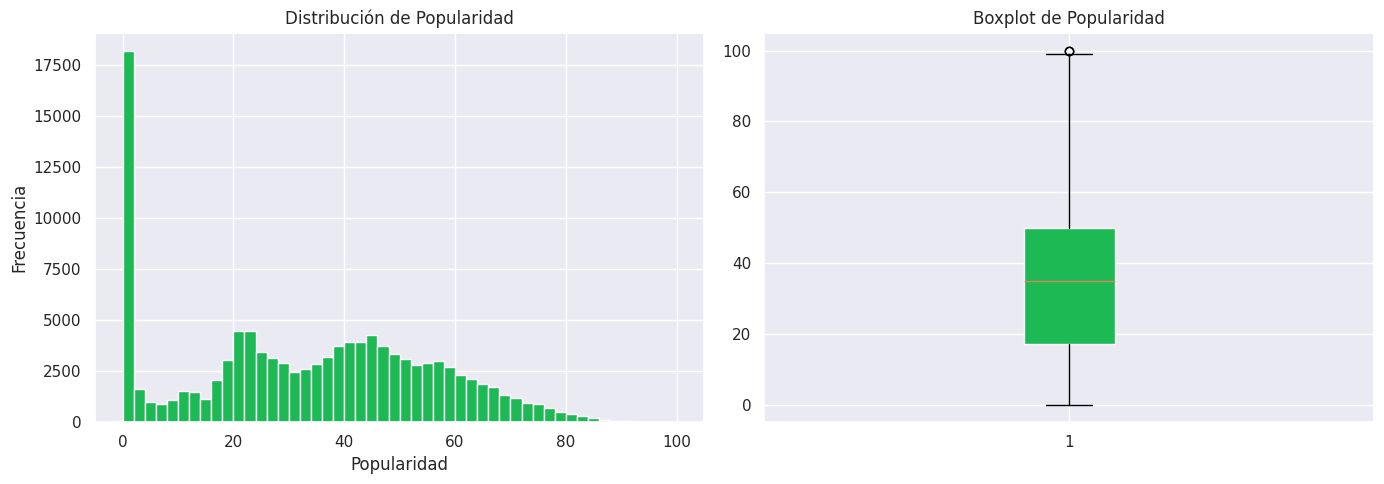

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df['popularity'], bins=50, color='#1DB954', edgecolor='white')
axes[0].set_title('Distribución de Popularidad')
axes[0].set_xlabel('Popularidad')
axes[0].set_ylabel('Frecuencia')

# Boxplot
axes[1].boxplot(df['popularity'], patch_artist=True,
                boxprops=dict(facecolor='#1DB954', color='white'))
axes[1].set_title('Boxplot de Popularidad')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/spotify-analysis/reports/popularity_dist.png', dpi=150)
plt.show()

**Heatmap de correlaciones**

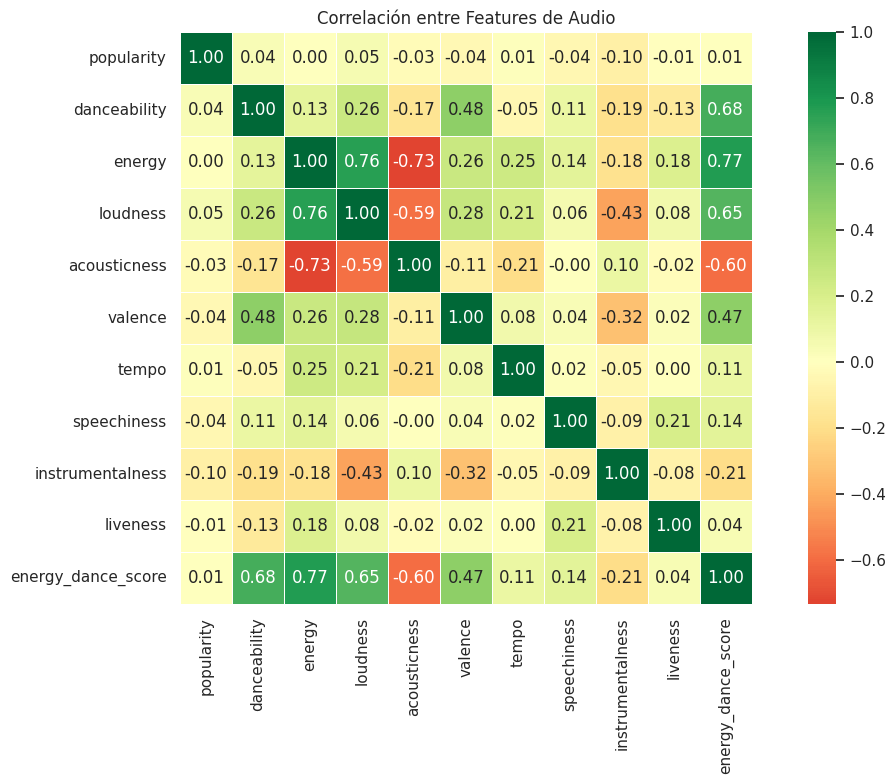

In [ ]:
features = ['popularity', 'danceability', 'energy', 'loudness',
            'acousticness', 'valence', 'tempo', 'speechiness',
            'instrumentalness', 'liveness', 'energy_dance_score']

corr = df[features].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5)
plt.title('Correlación entre Features de Audio')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/spotify-analysis/reports/correlations.png', dpi=150)
plt.show()

**¿Qué hace popular una canción?**

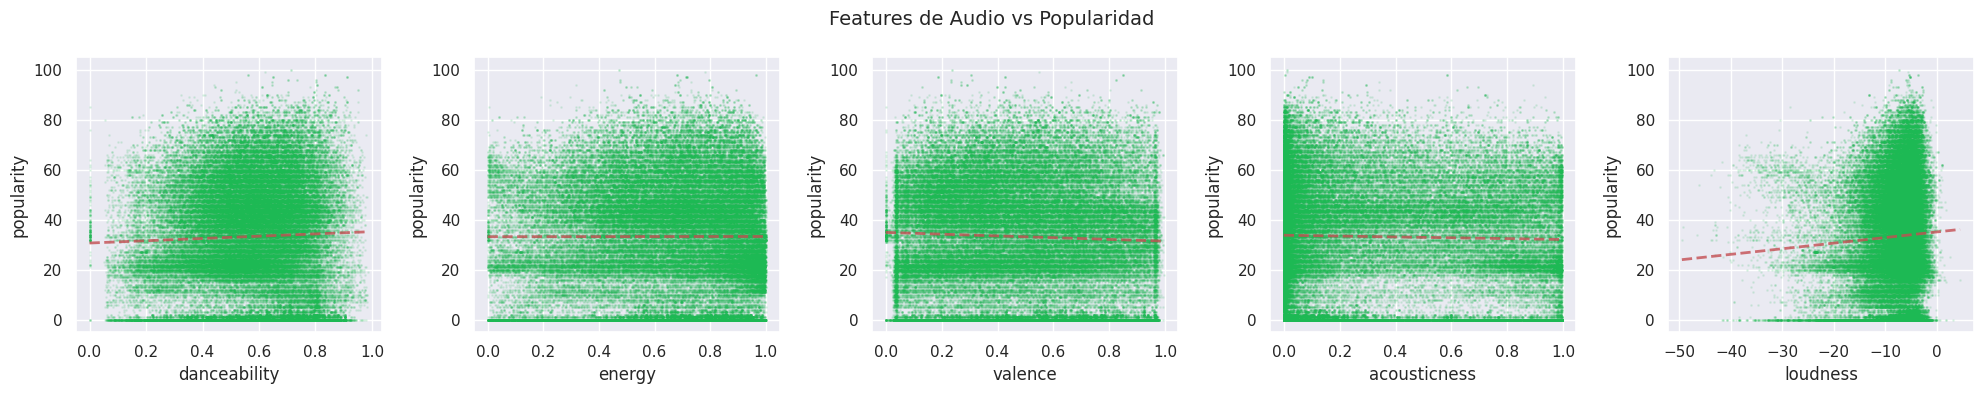

In [ ]:
features_vs_popularity = ['danceability', 'energy', 'valence', 'acousticness', 'loudness']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, feature in enumerate(features_vs_popularity):
    axes[i].scatter(df[feature], df['popularity'],
                   alpha=0.1, color='#1DB954', s=1)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('popularity')

    # Línea de tendencia
    z = np.polyfit(df[feature], df['popularity'], 1)
    p = np.poly1d(z)
    axes[i].plot(sorted(df[feature]), p(sorted(df[feature])),
                "r--", alpha=0.8, linewidth=2)

plt.suptitle('Features de Audio vs Popularidad', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/spotify-analysis/reports/features_vs_popularity.png', dpi=150)
plt.show()

**Comparación entre géneros**

/tmp/ipykernel_343/3216771583.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(genre_data, labels=top_genres, patch_artist=True)
/tmp/ipykernel_343/3216771583.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(genre_data, labels=top_genres, patch_artist=True)
/tmp/ipykernel_343/3216771583.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(genre_data, labels=top_genres, patch_artist=True)
/tmp/ipykernel_343/3216771583.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be drop

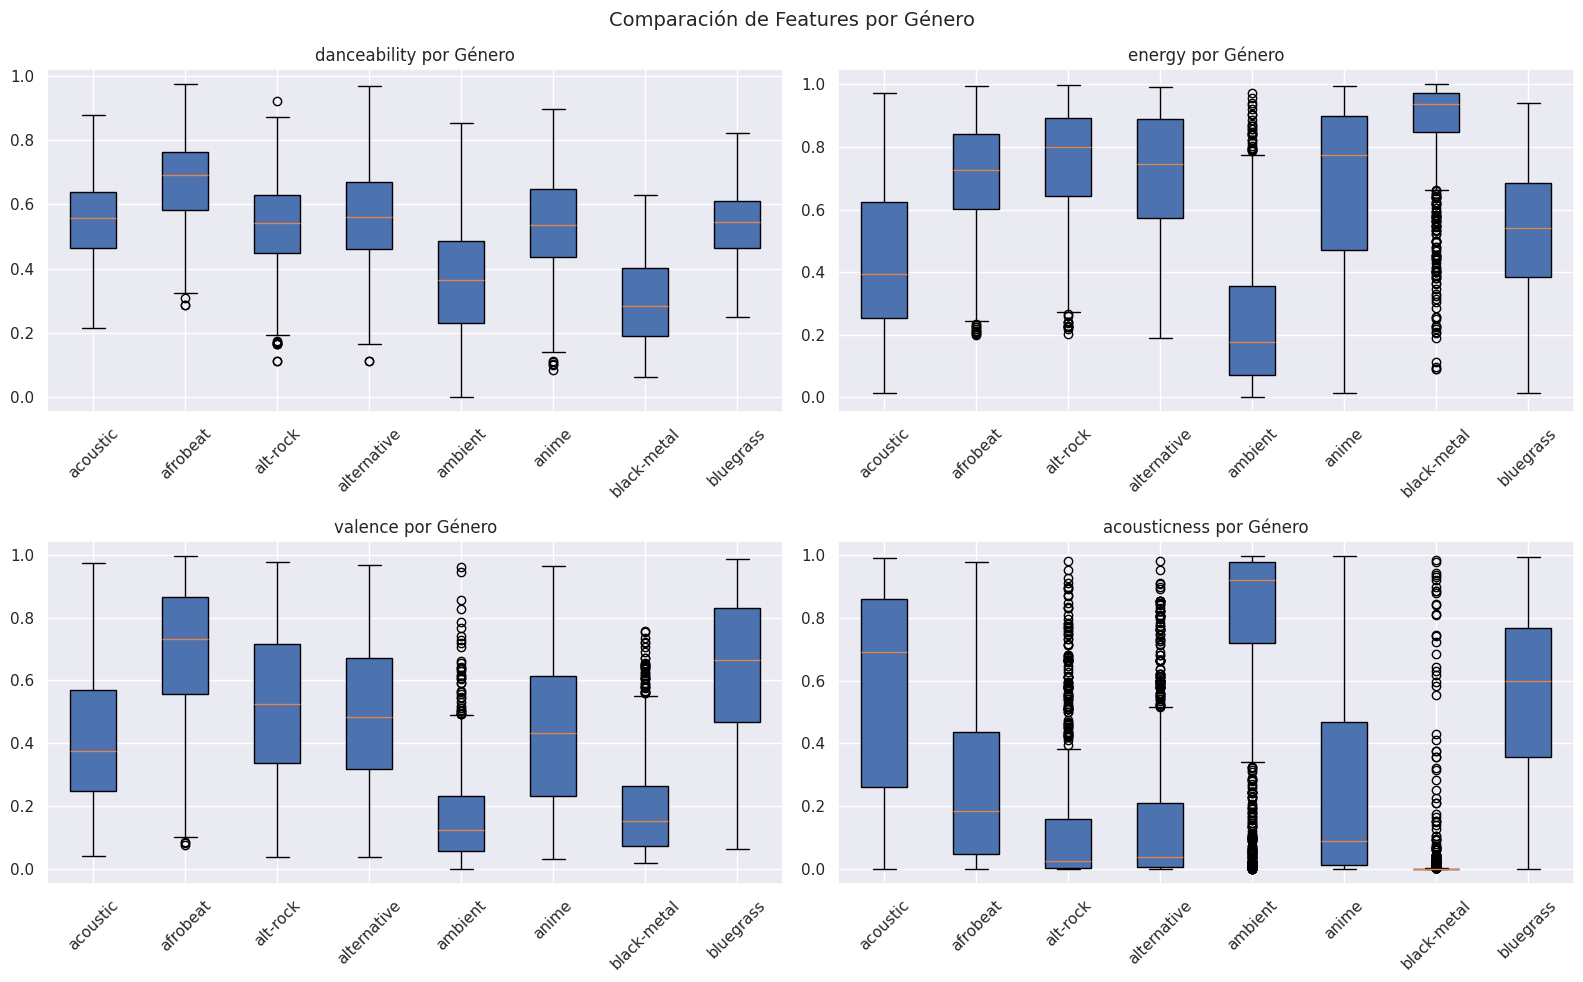

In [ ]:
# Top 8 géneros más frecuentes
top_genres = df['track_genre'].value_counts().head(8).index

df_top = df[df['track_genre'].isin(top_genres)]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

features_genre = ['danceability', 'energy', 'valence', 'acousticness']

for i, feature in enumerate(features_genre):
    ax = axes[i//2][i%2]
    genre_data = [df_top[df_top['track_genre'] == g][feature].values for g in top_genres]
    ax.boxplot(genre_data, labels=top_genres, patch_artist=True)
    ax.set_title(f'{feature} por Género')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Comparación de Features por Género', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/spotify-analysis/reports/genres_comparison.png', dpi=150)
plt.show()

** Canciones trending (popularity > 80)**

In [ ]:
trending = df[df['popularity'] > 80]

print(f"Canciones trending: {len(trending)}")
print(f"\nPromedios en canciones trending:")
print(trending[['danceability','energy','valence','tempo','duration_min']].mean().round(3))

print(f"\nPromedios en dataset completo:")
print(df[['danceability','energy','valence','tempo','duration_min']].mean().round(3))

Canciones trending: 954

Promedios en canciones trending:
danceability      0.658
energy            0.679
valence           0.508
tempo           118.427
duration_min      3.527
dtype: float64

Promedios en dataset completo:
danceability      0.567
energy            0.641
valence           0.474
tempo           122.148
duration_min      3.801
dtype: float64


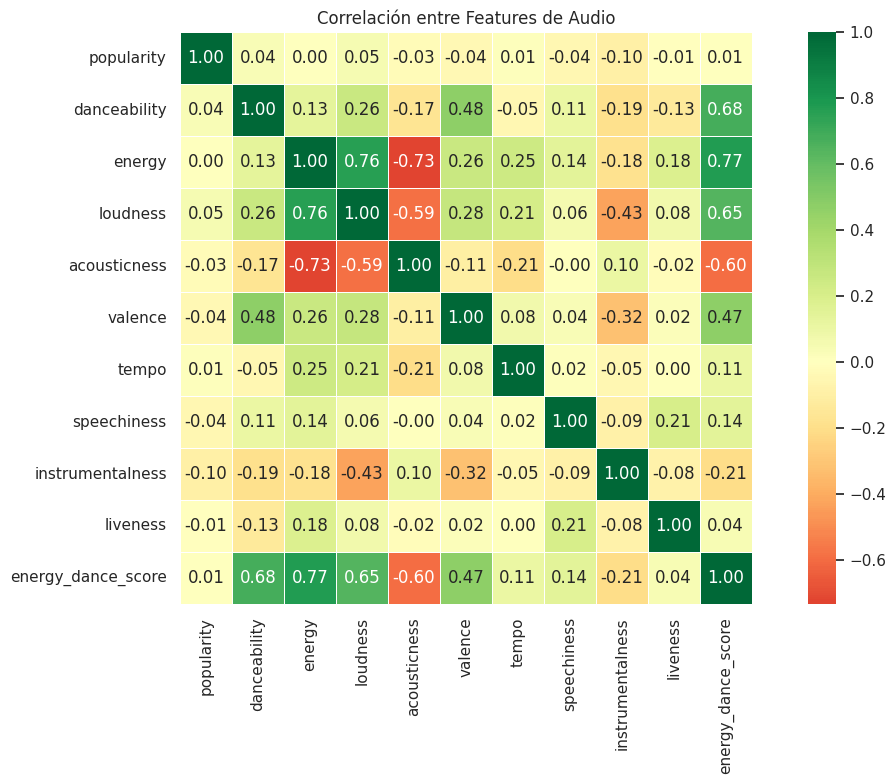

In [ ]:
features = ['popularity', 'danceability', 'energy', 'loudness',
            'acousticness', 'valence', 'tempo', 'speechiness',
            'instrumentalness', 'liveness', 'energy_dance_score']

corr = df[features].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5)
plt.title('Correlación entre Features de Audio')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/spotify-analysis/reports/correlations.png', dpi=150)
plt.show()